In [3]:
%pip install pandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path

ROOT = Path("/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox")

RAW_DEPTH_DIR    = ROOT / "depth_outputs"
TADN_DEPTH_DIR   = ROOT / "outputs_tadn"
BASELINE_OUT_DIR = ROOT / "outputs_baseline"
TADN_OUT_DIR     = ROOT / "tadn_rgb_generated_outputs"

DBG_ROOT = ROOT / "edge_debug_eval"
DBG_ROOT.mkdir(parents=True, exist_ok=True)

PROMPT_TYPES = ["basic", "structured", "thermal_aware"]
IMAGE_IDS = range(1, 10)

In [6]:
def load_gray(path: Path):
    return np.array(Image.open(path).convert("L"))

def load_rgb(path: Path):
    return np.array(Image.open(path).convert("RGB"))

def auto_canny(img_u8, sigma=0.25):
    v = np.median(img_u8)
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edges = cv2.Canny(img_u8, lower, upper)
    return (edges > 0).astype(np.uint8), (lower, upper)

def eval_pair(depth_gray, rgb_gray, tol=9):
    depth_s = cv2.GaussianBlur(depth_gray, (5, 5), 0)
    rgb_s   = cv2.GaussianBlur(rgb_gray,   (7, 7), 0)

    edge_depth, (dl, du) = auto_canny(depth_s, sigma=0.25)
    edge_rgb,   (rl, ru) = auto_canny(rgb_s,   sigma=0.20)

    kernel = np.ones((tol, tol), np.uint8)
    depth_tol = cv2.dilate(edge_depth, kernel, 1)
    rgb_tol   = cv2.dilate(edge_rgb,   kernel, 1)

    tp = int(((edge_rgb == 1) & (depth_tol == 1)).sum())
    fp = int(((edge_rgb == 1) & (depth_tol == 0)).sum())
    fn = int(((edge_depth == 1) & (rgb_tol == 0)).sum())

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    meta = {
        "edge_depth": int(edge_depth.sum()),
        "edge_rgb": int(edge_rgb.sum()),
        "depth_canny": (dl, du),
        "rgb_canny": (rl, ru),
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "edge_depth_img": edge_depth,
        "edge_rgb_img": edge_rgb
    }
    return precision, recall, f1, meta

In [ ]:
rows = []

for i in IMAGE_IDS:
    image_key = f"t{i}"

    raw_depth_path  = RAW_DEPTH_DIR  / f"{image_key}_depth.png"
    tadn_depth_path = TADN_DEPTH_DIR / f"{image_key}_depth_tadn_safe.png"

    for prompt_type in PROMPT_TYPES:
        baseline_rgb_path = BASELINE_OUT_DIR / f"{image_key}_{prompt_type}_baseline.png"
        tadn_rgb_path     = TADN_OUT_DIR     / f"{image_key}_{prompt_type}_tadn.png"

        # Baseline
        if raw_depth_path.exists() and baseline_rgb_path.exists():
            depth_gray = load_gray(raw_depth_path)
            rgb = load_rgb(baseline_rgb_path)
            rgb_gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            rgb_gray = cv2.resize(
                rgb_gray,
                (depth_gray.shape[1], depth_gray.shape[0]),
                interpolation=cv2.INTER_AREA
            )

            p, r, f1, meta = eval_pair(depth_gray, rgb_gray, tol=9)

            rows.append({
                "image": image_key,
                "prompt_type": prompt_type,
                "pipeline": "baseline",
                "precision": p,
                "recall": r,
                "f1": f1,
                "edge_depth": meta["edge_depth"],
                "edge_rgb": meta["edge_rgb"]
            })

            dbg = DBG_ROOT / image_key / prompt_type / "baseline"
            dbg.mkdir(parents=True, exist_ok=True)

            cv2.imwrite(str(dbg / "edge_depth.png"), meta["edge_depth_img"] * 255)
            cv2.imwrite(str(dbg / "edge_rgb.png"), meta["edge_rgb_img"] * 255)

            rgb_resized = cv2.resize(
                rgb,
                (depth_gray.shape[1], depth_gray.shape[0]),
                interpolation=cv2.INTER_AREA
            )
            overlay = rgb_resized.copy()
            overlay[meta["edge_rgb_img"] == 1] = [255, 0, 0] 
            overlay[meta["edge_depth_img"] == 1] = [0, 255, 0] 
            cv2.imwrite(str(dbg / "overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        else:
            print(f"Missing baseline files for {image_key} / {prompt_type}")

        # TADN
        if tadn_depth_path.exists() and tadn_rgb_path.exists():
            depth_gray = load_gray(tadn_depth_path)
            rgb = load_rgb(tadn_rgb_path)
            rgb_gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
            rgb_gray = cv2.resize(
                rgb_gray,
                (depth_gray.shape[1], depth_gray.shape[0]),
                interpolation=cv2.INTER_AREA
            )

            p, r, f1, meta = eval_pair(depth_gray, rgb_gray, tol=9)

            rows.append({
                "image": image_key,
                "prompt_type": prompt_type,
                "pipeline": "tadn",
                "precision": p,
                "recall": r,
                "f1": f1,
                "edge_depth": meta["edge_depth"],
                "edge_rgb": meta["edge_rgb"]
            })

            dbg = DBG_ROOT / image_key / prompt_type / "tadn"
            dbg.mkdir(parents=True, exist_ok=True)

            cv2.imwrite(str(dbg / "edge_depth.png"), meta["edge_depth_img"] * 255)
            cv2.imwrite(str(dbg / "edge_rgb.png"), meta["edge_rgb_img"] * 255)

            rgb_resized = cv2.resize(
                rgb,
                (depth_gray.shape[1], depth_gray.shape[0]),
                interpolation=cv2.INTER_AREA
            )
            overlay = rgb_resized.copy()
            overlay[meta["edge_rgb_img"] == 1] = [255, 0, 0]
            overlay[meta["edge_depth_img"] == 1] = [0, 255, 0]
            cv2.imwrite(str(dbg / "overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        else:
            print(f"Missing TADN files for {image_key} / {prompt_type}")

results_df = pd.DataFrame(rows)
results_df

,image,prompt_type,pipeline,precision,recall,f1,edge_depth,edge_rgb
0,t1,basic,baseline,0.000000,0.000000,0.000000,0,10164
1,t1,basic,tadn,0.000000,0.000000,0.000000,0,7228
2,t1,structured,baseline,0.000000,0.000000,0.000000,0,10996
3,t1,structured,tadn,0.000000,0.000000,0.000000,0,7989
4,t1,thermal_aware,baseline,0.000000,0.000000,0.000000,0,8683
5,t1,thermal_aware,tadn,0.000000,0.000000,0.000000,0,10500
6,t2,basic,baseline,0.012617,0.987654,0.024916,120,12681
7,t2,basic,tadn,0.000000,0.000000,0.000000,120,1758
8,t2,structured,baseline,0.013520,0.835821,0.026610,120,8284
9,t2,structured,tadn,0.002799,0.352381,0.005554,120,13218


In [8]:
valid_df = results_df[results_df["edge_depth"] > 0].copy()

print("Number of total rows:", len(results_df))
print("Number of valid rows:", len(valid_df))

display(valid_df.head())

Number of total rows: 54
Number of valid rows: 36


,image,prompt_type,pipeline,precision,recall,f1,edge_depth,edge_rgb
6,t2,basic,baseline,0.012617,0.987654,0.024916,120,12681
7,t2,basic,tadn,0.000000,0.000000,0.000000,120,1758
8,t2,structured,baseline,0.013520,0.835821,0.026610,120,8284
9,t2,structured,tadn,0.002799,0.352381,0.005554,120,13218
10,t2,thermal_aware,baseline,0.005757,0.395349,0.011348,120,8859


In [9]:
summary_by_pipeline = results_df.groupby("pipeline")[["precision", "recall", "f1"]].mean().round(3)
summary_by_prompt = results_df.groupby(["prompt_type", "pipeline"])[["precision", "recall", "f1"]].mean().round(3)

print("Average by pipeline")
display(summary_by_pipeline)

print("\nAverage by prompt type and pipeline")
display(summary_by_prompt)

Average by pipeline


,precision,recall,f1
pipeline,,,
baseline,0.013,0.320,0.025
tadn,0.012,0.298,0.022



Average by prompt type and pipeline


precision  recall     f1
prompt_type   pipeline                          
basic         baseline      0.012   0.403  0.024
              tadn          0.011   0.327  0.020
structured    baseline      0.016   0.387  0.029
              tadn          0.012   0.307  0.023
thermal_aware baseline      0.012   0.168  0.021
              tadn          0.013   0.261  0.024

In [10]:
summary_valid_pipeline = (
    valid_df
    .groupby("pipeline")[["precision", "recall", "f1"]]
    .mean()
    .round(3)
)

print("Valid-case average by pipeline")
display(summary_valid_pipeline)

Valid-case average by pipeline


,precision,recall,f1
pipeline,,,
baseline,0.020,0.479,0.037
tadn,0.018,0.447,0.034


In [11]:
summary_valid_prompt = (
    valid_df
    .groupby(["prompt_type", "pipeline"])[["precision", "recall", "f1"]]
    .mean()
    .round(3)
)

print("Valid-case average by prompt type and pipeline")
display(summary_valid_prompt)

Valid-case average by prompt type and pipeline


precision  recall     f1
prompt_type   pipeline                          
basic         baseline      0.018   0.605  0.035
              tadn          0.016   0.490  0.030
structured    baseline      0.023   0.581  0.044
              tadn          0.018   0.460  0.034
thermal_aware baseline      0.018   0.253  0.032
              tadn          0.019   0.391  0.036

In [12]:
comparison_df = (
    valid_df
    .pivot_table(
        index=["image", "prompt_type"],
        columns="pipeline",
        values="f1"
    )
    .reset_index()
)

comparison_df["f1_improvement"] = comparison_df["tadn"] - comparison_df["baseline"]
comparison_df = comparison_df.round(3)

print("Baseline vs TADN F1 comparison")
display(comparison_df)

Baseline vs TADN F1 comparison


pipeline,image,prompt_type,baseline,tadn,f1_improvement
0,t2,basic,0.025,0.000,-0.025
1,t2,structured,0.027,0.006,-0.021
2,t2,thermal_aware,0.011,0.000,-0.011
3,t3,basic,0.045,0.008,-0.037
4,t3,structured,0.055,0.005,-0.051
5,t3,thermal_aware,0.029,0.028,-0.001
6,t4,basic,0.103,0.129,0.025
7,t4,structured,0.139,0.154,0.014
8,t4,thermal_aware,0.148,0.156,0.009
9,t6,basic,0.039,0.035,-0.004


In [13]:
print("Top TADN improvements")
display(comparison_df.sort_values("f1_improvement", ascending=False).head(10))

print("Largest TADN drops")
display(comparison_df.sort_values("f1_improvement", ascending=True).head(10))

Top TADN improvements


pipeline,image,prompt_type,baseline,tadn,f1_improvement
11,t6,thermal_aware,0.000,0.034,0.034
6,t4,basic,0.103,0.129,0.025
7,t4,structured,0.139,0.154,0.014
15,t9,basic,0.000,0.010,0.010
8,t4,thermal_aware,0.148,0.156,0.009
13,t8,structured,0.004,0.005,0.001
12,t8,basic,0.000,0.000,0.000
16,t9,structured,0.002,0.001,-0.000
17,t9,thermal_aware,0.001,0.000,-0.001
5,t3,thermal_aware,0.029,0.028,-0.001


Largest TADN drops


pipeline,image,prompt_type,baseline,tadn,f1_improvement
4,t3,structured,0.055,0.005,-0.051
3,t3,basic,0.045,0.008,-0.037
0,t2,basic,0.025,0.000,-0.025
1,t2,structured,0.027,0.006,-0.021
2,t2,thermal_aware,0.011,0.000,-0.011
14,t8,thermal_aware,0.004,0.000,-0.004
9,t6,basic,0.039,0.035,-0.004
10,t6,structured,0.037,0.034,-0.003
17,t9,thermal_aware,0.001,0.000,-0.001
5,t3,thermal_aware,0.029,0.028,-0.001


In [14]:
comparison_df["tadn_better"] = comparison_df["tadn"] > comparison_df["baseline"]

win_count = int(comparison_df["tadn_better"].sum())
total_count = len(comparison_df)

print(f"TADN better in {win_count} out of {total_count} valid comparisons.")

TADN better in 6 out of 18 valid comparisons.


In [32]:
wins_by_prompt = (
    comparison_df
    .groupby("prompt_type")["tadn_better"]
    .agg(["sum", "count"])
)

wins_by_prompt["win_rate"] = (wins_by_prompt["sum"] / wins_by_prompt["count"]).round(3)

print("TADN wins by prompt type")
display(wins_by_prompt)

TADN wins by prompt type


,sum,count,win_rate
prompt_type,,,
basic,2,6,0.333
structured,2,6,0.333
thermal_aware,2,6,0.333


In [15]:
def label_change(x):
    if x > 0:
        return "improved"
    elif x < 0:
        return "worse"
    else:
        return "same"

comparison_df["tadn_effect"] = comparison_df["f1_improvement"].apply(label_change)

display(comparison_df)

pipeline,image,prompt_type,baseline,tadn,f1_improvement,tadn_better,tadn_effect
0,t2,basic,0.025,0.000,-0.025,False,worse
1,t2,structured,0.027,0.006,-0.021,False,worse
2,t2,thermal_aware,0.011,0.000,-0.011,False,worse
3,t3,basic,0.045,0.008,-0.037,False,worse
4,t3,structured,0.055,0.005,-0.051,False,worse
5,t3,thermal_aware,0.029,0.028,-0.001,False,worse
6,t4,basic,0.103,0.129,0.025,True,improved
7,t4,structured,0.139,0.154,0.014,True,improved
8,t4,thermal_aware,0.148,0.156,0.009,True,improved
9,t6,basic,0.039,0.035,-0.004,False,worse


In [16]:
summary_valid_pipeline.to_csv(ROOT / "summary_valid_pipeline.csv")
summary_valid_prompt.to_csv(ROOT / "summary_valid_prompt.csv")
comparison_df.to_csv(ROOT / "comparison_valid_f1.csv", index=False)

print("Saved valid-case summary tables.")

Saved valid-case summary tables.


ROOT: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox
Results CSV exists: False
Output folder: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs
Using existing results_df already in notebook


,image,prompt_type,pipeline,precision,recall,f1,edge_depth,edge_rgb
0,t1,basic,baseline,0.0,0.0,0.0,0,10164
1,t1,basic,tadn,0.0,0.0,0.0,0,7228
2,t1,structured,baseline,0.0,0.0,0.0,0,10996
3,t1,structured,tadn,0.0,0.0,0.0,0,7989
4,t1,thermal_aware,baseline,0.0,0.0,0.0,0,8683


Shape: (54, 8)
Total rows: 54
Valid rows: 36


,image,prompt_type,pipeline,precision,recall,f1,edge_depth,edge_rgb
6,t2,basic,baseline,0.012617,0.987654,0.024916,120,12681
7,t2,basic,tadn,0.000000,0.000000,0.000000,120,1758
8,t2,structured,baseline,0.013520,0.835821,0.026610,120,8284
9,t2,structured,tadn,0.002799,0.352381,0.005554,120,13218
10,t2,thermal_aware,baseline,0.005757,0.395349,0.011348,120,8859


Table 3.1:


...

pipeline,image,prompt_type,baseline,tadn,f1_improvement
4,t3,structured,0.055,0.005,-0.051
3,t3,basic,0.045,0.008,-0.037
0,t2,basic,0.025,0.000,-0.025
1,t2,structured,0.027,0.006,-0.021
2,t2,thermal_aware,0.011,0.000,-0.011
14,t8,thermal_aware,0.004,0.000,-0.004
9,t6,basic,0.039,0.035,-0.004
10,t6,structured,0.037,0.034,-0.003
17,t9,thermal_aware,0.001,0.000,-0.001
5,t3,thermal_aware,0.029,0.028,-0.001


TADN better in 6 out of 18 valid comparisons.
TADN wins by prompt type:


,sum,count,win_rate
prompt_type,,,
basic,2,6,0.333
structured,2,6,0.333
thermal_aware,2,6,0.333


Plot data:


,prompt_type,pipeline,f1
0,basic,baseline,0.035
1,basic,tadn,0.030
2,structured,baseline,0.044
3,structured,tadn,0.034
4,thermal_aware,baseline,0.032
5,thermal_aware,tadn,0.036


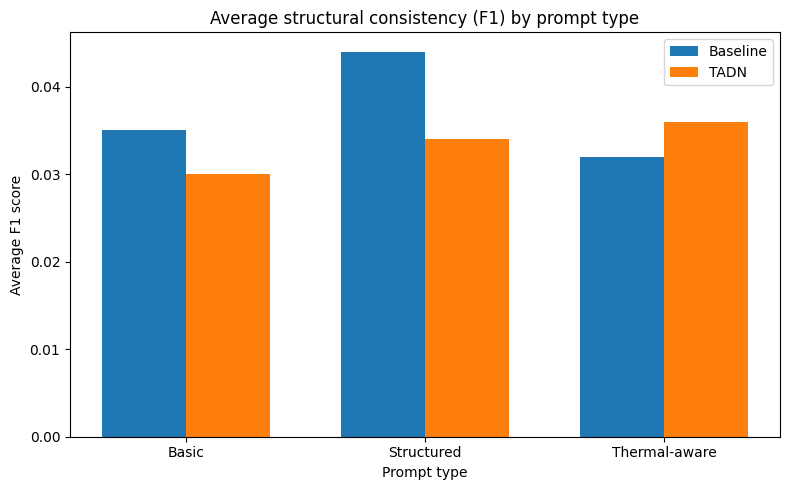

Saved Figure 3.1: /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/figure_3_1_f1_by_prompt.png
Word-friendly Table 3.1:


,prompt_type,pipeline,precision,recall,f1
0,Basic,Baseline,0.018,0.605,0.035
1,Basic,TADN,0.016,0.490,0.030
2,Structured,Baseline,0.023,0.581,0.044
3,Structured,TADN,0.018,0.460,0.034
4,Thermal-aware,Baseline,0.018,0.253,0.032
5,Thermal-aware,TADN,0.019,0.391,0.036



Saved files:
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/table_3_1_quantitative_results.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/table_3_1_quantitative_results_pivot.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/overall_pipeline_summary.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/comparison_valid_f1.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/top_tadn_improvements.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/largest_tadn_drops.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/wins_by_prompt.csv
- /Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox/dissertation_outputs/figure_3_1_f1_by_prompt.png
- /Users/maryamellathy/Desktop/NE

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

ROOT = Path("/Users/maryamellathy/Desktop/NEW thermaltoRBG/Thermal_Depth_Sandbox")

RESULTS_CSV = ROOT / "evaluation_results_long.csv"

OUT_DIR = ROOT / "dissertation_outputs"
OUT_DIR.mkdir(exist_ok=True)

print("ROOT:", ROOT)
print("Results CSV exists:", RESULTS_CSV.exists())
print("Output folder:", OUT_DIR)

print("Using existing results_df already in notebook")

display(results_df.head())
print("Shape:", results_df.shape)

valid_df = results_df[results_df["edge_depth"] > 0].copy()

print("Total rows:", len(results_df))
print("Valid rows:", len(valid_df))

display(valid_df.head())

table_3_1 = (
    valid_df
    .groupby(["prompt_type", "pipeline"])[["precision", "recall", "f1"]]
    .mean()
    .round(3)
    .reset_index()
)

print("Table 3.1:")
display(table_3_1)


table_3_1_csv = OUT_DIR / "table_3_1_quantitative_results.csv"
table_3_1.to_csv(table_3_1_csv, index=False)


table_3_1_pivot = (
    table_3_1
    .pivot(index="prompt_type", columns="pipeline", values=["precision", "recall", "f1"])
    .round(3)
)

print("Table 3.1 (pivoted):")
display(table_3_1_pivot)

table_3_1_pivot_csv = OUT_DIR / "table_3_1_quantitative_results_pivot.csv"
table_3_1_pivot.to_csv(table_3_1_pivot_csv)

overall_pipeline_summary = (
    valid_df
    .groupby("pipeline")[["precision", "recall", "f1"]]
    .mean()
    .round(3)
)

print("Overall average by pipeline:")
display(overall_pipeline_summary)

overall_pipeline_csv = OUT_DIR / "overall_pipeline_summary.csv"
overall_pipeline_summary.to_csv(overall_pipeline_csv)

comparison_df = (
    valid_df
    .pivot_table(
        index=["image", "prompt_type"],
        columns="pipeline",
        values="f1"
    )
    .reset_index()
)

comparison_df["f1_improvement"] = comparison_df["tadn"] - comparison_df["baseline"]
comparison_df = comparison_df.round(3)

print("Baseline vs TADN comparison:")
display(comparison_df)

comparison_csv = OUT_DIR / "comparison_valid_f1.csv"
comparison_df.to_csv(comparison_csv, index=False)

best_improvements = comparison_df.sort_values("f1_improvement", ascending=False)
print("Top TADN improvements:")
display(best_improvements.head(10))

best_improvements_csv = OUT_DIR / "top_tadn_improvements.csv"
best_improvements.to_csv(best_improvements_csv, index=False)

largest_drops = comparison_df.sort_values("f1_improvement", ascending=True)
print("Largest TADN drops:")
display(largest_drops.head(10))

largest_drops_csv = OUT_DIR / "largest_tadn_drops.csv"
largest_drops.to_csv(largest_drops_csv, index=False)

comparison_df["tadn_better"] = comparison_df["tadn"] > comparison_df["baseline"]

win_count = int(comparison_df["tadn_better"].sum())
total_count = len(comparison_df)

print(f"TADN better in {win_count} out of {total_count} valid comparisons.")

wins_by_prompt = (
    comparison_df
    .groupby("prompt_type")["tadn_better"]
    .agg(["sum", "count"])
)

wins_by_prompt["win_rate"] = (wins_by_prompt["sum"] / wins_by_prompt["count"]).round(3)

print("TADN wins by prompt type:")
display(wins_by_prompt)

wins_by_prompt_csv = OUT_DIR / "wins_by_prompt.csv"
wins_by_prompt.to_csv(wins_by_prompt_csv)

f1_plot = (
    valid_df
    .groupby(["prompt_type", "pipeline"])["f1"]
    .mean()
    .round(3)
    .reset_index()
)

prompt_order = ["basic", "structured", "thermal_aware"]
f1_plot["prompt_type"] = pd.Categorical(
    f1_plot["prompt_type"],
    categories=prompt_order,
    ordered=True
)
f1_plot = f1_plot.sort_values(["prompt_type", "pipeline"])

print("Plot data:")
display(f1_plot)

baseline_vals = f1_plot[f1_plot["pipeline"] == "baseline"]["f1"].values
tadn_vals = f1_plot[f1_plot["pipeline"] == "tadn"]["f1"].values

x = np.arange(len(prompt_order))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, baseline_vals, width, label="Baseline")
plt.bar(x + width/2, tadn_vals, width, label="TADN")

plt.xticks(x, ["Basic", "Structured", "Thermal-aware"])
plt.ylabel("Average F1 score")
plt.xlabel("Prompt type")
plt.title("Average structural consistency (F1) by prompt type")
plt.legend()
plt.tight_layout()

figure_3_1_path = OUT_DIR / "figure_3_1_f1_by_prompt.png"
plt.savefig(figure_3_1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved Figure 3.1:", figure_3_1_path)

word_table = table_3_1.copy()
word_table["prompt_type"] = word_table["prompt_type"].replace({
    "basic": "Basic",
    "structured": "Structured",
    "thermal_aware": "Thermal-aware"
})
word_table["pipeline"] = word_table["pipeline"].replace({
    "baseline": "Baseline",
    "tadn": "TADN"
})

print("Word-friendly Table 3.1:")
display(word_table)

word_table_csv = OUT_DIR / "table_3_1_word_friendly.csv"
word_table.to_csv(word_table_csv, index=False)

print("\nSaved files:")
print("-", table_3_1_csv)
print("-", table_3_1_pivot_csv)
print("-", overall_pipeline_csv)
print("-", comparison_csv)
print("-", best_improvements_csv)
print("-", largest_drops_csv)
print("-", wins_by_prompt_csv)
print("-", figure_3_1_path)
print("-", word_table_csv)

In [19]:
table_3_1 = (
    valid_df
    .groupby(['prompt_type', 'pipeline'])[['precision', 'recall', 'f1']]
    .mean()
    .reset_index()
)
table_3_1.round(3).to_csv("table_3_1.csv", index=False)
print(table_3_1)

     prompt_type  pipeline  precision    recall        f1
0          basic  baseline   0.018355  0.604680  0.035313
1          basic      tadn   0.015915  0.490217  0.030163
2     structured  baseline   0.023312  0.581082  0.043955
3     structured      tadn   0.018186  0.460137  0.033970
4  thermal_aware  baseline   0.017872  0.252632  0.032233
5  thermal_aware      tadn   0.019498  0.391132  0.036390
